<div style="
    background-color:#cfe6ff;
    color:#000000;
    padding:16px;
    margin-bottom:16px;
">
<b>PROYECTO FINAL — ANÁLISIS DE MÚSICA</b><br>
Análisis temporal, emocional y sonoro de canciones (1950–2019)<br>
Dataset: letras + audio features Spotify<br>
Objetivo: explorar cómo cambia la música y su sentimiento a lo largo del tiempo
</div>




In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from wordcloud import STOPWORDS


In [72]:
import matplotlib.font_manager as fm


In [73]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [74]:
# Cargar dataset original
df_raw = pd.read_csv("../data/tcc_ceds_music.csv")

# Crear copia de trabajo
df_music = df_raw.copy()

df_music = df_music.drop(columns=["Unnamed: 0"])

# Craer columna ["Decade"]
df_music.insert(
    df_music.columns.get_loc("release_date") + 1,
    "decade",
    (df_music["release_date"] // 10) * 10
)

df_music.head()


,artist_name,track_name,release_date,decade,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,mukesh,mohabbat bhi jhoothi,1950,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,frankie laine,i believe,1950,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,johnnie ray,cry,1950,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,pérez prado,patricia,1950,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,giorgos papadopoulos,apopse eida oneiro,1950,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


In [75]:
df_music.shape

(28372, 31)

In [76]:
df_music.tail()


,artist_name,track_name,release_date,decade,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
28367,mack 10,10 million ways,2019,2010,hip hop,cause fuck leave scar tick tock clock come kno...,78,0.001350,0.001350,0.001350,...,0.065664,0.001350,0.889527,0.759711,0.062549,0.000000,0.751649,0.695686,obscene,0.014286
28368,m.o.p.,ante up (robbin hoodz theory),2019,2010,hip hop,minks things chain ring braclets yap fame come...,67,0.001284,0.001284,0.035338,...,0.001284,0.001284,0.662082,0.789580,0.004607,0.000002,0.922712,0.797791,obscene,0.014286
28369,nine,whutcha want?,2019,2010,hip hop,get ban get ban stick crack relax plan attack ...,77,0.001504,0.154302,0.168988,...,0.001504,0.001504,0.663165,0.726970,0.104417,0.000001,0.838211,0.767761,obscene,0.014286
28370,will smith,switch,2019,2010,hip hop,check check yeah yeah hear thing call switch g...,67,0.001196,0.001196,0.001196,...,0.001196,0.001196,0.883028,0.786888,0.007027,0.000503,0.508450,0.885882,obscene,0.014286
28371,jeezy,r.i.p.,2019,2010,hip hop,remix killer alive remix thriller trap bitch s...,83,0.001012,0.075202,0.001012,...,0.001012,0.033995,0.828875,0.674794,0.015862,0.000000,0.475474,0.492477,obscene,0.014286


In [77]:
df_music.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28372 entries, 0 to 28371
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist_name               28372 non-null  object 
 1   track_name                28372 non-null  object 
 2   release_date              28372 non-null  int64  
 3   decade                    28372 non-null  int64  
 4   genre                     28372 non-null  object 
 5   lyrics                    28372 non-null  object 
 6   len                       28372 non-null  int64  
 7   dating                    28372 non-null  float64
 8   violence                  28372 non-null  float64
 9   world/life                28372 non-null  float64
 10  night/time                28372 non-null  float64
 11  shake the audience        28372 non-null  float64
 12  family/gospel             28372 non-null  float64
 13  romantic                  28372 non-null  float64
 14  commun

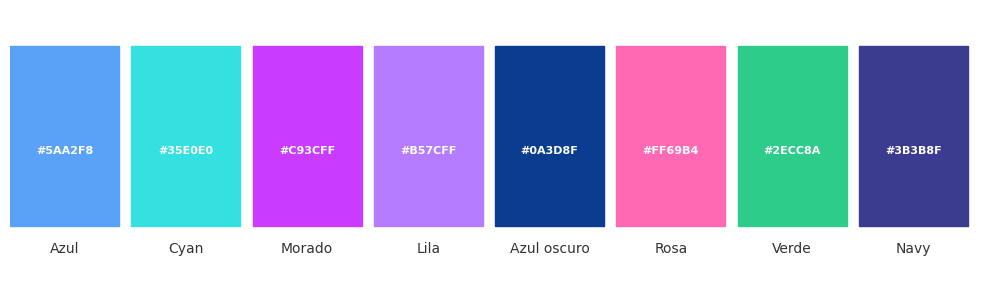

In [78]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = {
    "Azul": "#5AA2F8",
    "Cyan": "#35E0E0",
    "Morado": "#C93CFF",
    "Lila": "#B57CFF",
    "Azul oscuro": "#0A3D8F",
    "Rosa": "#FF69B4",
    "Verde": "#2ECC8A",
    "Navy": "#3B3B8F"
}

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

for i, (name, color) in enumerate(colors.items()):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 1, color=color))
    ax.text(i + 0.45, -0.15, name, ha="center", fontsize=10, color="#333333")
    ax.text(i + 0.45, 0.4, color, ha="center", fontsize=8, color="white", fontweight="bold")

ax.set_xlim(0, len(colors))
ax.set_ylim(-0.3, 1.2)
plt.tight_layout()
plt.show()

In [79]:
df_music.describe().round(2)

,release_date,decade,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,...,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,age
count,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,...,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00,28372.00
mean,1990.24,1985.55,73.03,0.02,0.12,0.12,0.06,0.02,0.02,0.05,...,0.03,0.13,0.03,0.53,0.67,0.34,0.08,0.53,0.57,0.43
std,18.49,18.43,41.83,0.05,0.18,0.17,0.11,0.04,0.04,0.11,...,0.06,0.18,0.07,0.17,0.11,0.33,0.21,0.25,0.24,0.26
min,1950.00,1950.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.01
25%,1975.00,1970.00,42.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.41,0.60,0.03,0.00,0.33,0.38,0.19
50%,1991.00,1990.00,63.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,...,0.00,0.01,0.00,0.54,0.68,0.23,0.00,0.54,0.58,0.41
75%,2007.00,2000.00,93.00,0.00,0.19,0.20,0.07,0.01,0.00,0.04,...,0.03,0.24,0.03,0.66,0.75,0.63,0.01,0.74,0.77,0.64
max,2019.00,2010.00,199.00,0.65,0.98,0.96,0.97,0.50,0.55,0.94,...,0.59,0.98,0.96,0.99,1.00,1.00,1.00,1.00,1.00,1.00


In [80]:
df_music.isna().sum()

artist_name                 0
track_name                  0
release_date                0
decade                      0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
like/girls                  0
sadness                     0
feelings                    0
danceability                0
loudness                    0
acousticness                0
instrumentalness            0
valence                     0
energy                      0
topic                       0
age                         0
dtype: int64

In [81]:
df_decade = df_music.groupby("decade")[[
    "sadness",
    "romantic",
    "violence",
    "obscene",
    "danceability",
    "loudness",
    "acousticness",
    "energy",
    "valence"
]].mean()

df_decade


,sadness,romantic,violence,obscene,danceability,loudness,acousticness,energy,valence
decade,,,,,,,,,
1950,0.141258,0.121139,0.057595,0.057481,0.470689,0.588890,0.804829,0.312325,0.499630
1960,0.154476,0.081477,0.066468,0.054842,0.485890,0.613339,0.622914,0.414836,0.564931
1970,0.118324,0.050219,0.101586,0.065129,0.510577,0.618376,0.371590,0.524892,0.579475
1980,0.145078,0.045184,0.132234,0.075054,0.538657,0.624366,0.263424,0.583139,0.569479
1990,0.135151,0.042509,0.128434,0.098383,0.539857,0.661032,0.279943,0.586370,0.521222
2000,0.121569,0.035081,0.139021,0.112486,0.544614,0.725510,0.248417,0.655217,0.507281
2010,0.107926,0.028194,0.140535,0.160010,0.575267,0.735586,0.210393,0.665913,0.489945


In [82]:
df_music["genre"].unique()

array(['pop', 'country', 'blues', 'jazz', 'reggae', 'rock', 'hip hop'],
      dtype=object)

In [83]:
df_music["genre"].value_counts(normalize=True).mul(100).round(1)

genre
pop        24.8
country    19.2
blues      16.2
rock       14.2
jazz       13.6
reggae      8.8
hip hop     3.2
Name: proportion, dtype: float64

In [84]:
df_music["genre"].value_counts()

genre
pop        7042
country    5445
blues      4604
rock       4034
jazz       3845
reggae     2498
hip hop     904
Name: count, dtype: int64

In [85]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [86]:
from IPython.display import display, HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Arimo:wght@400;700&display=swap');
</style>
"""))

UNIVERSO DE LOS GENEROS

In [87]:
import plotly.graph_objects as go

genres = ["Pop", "Country", "Blues", "Rock", "Jazz", "Reggae", "Hip Hop"]
percentages = [24.8, 19.2, 16.2, 14.2, 13.6, 8.8, 3.2]
counts = [7042, 5445, 4604, 4034, 3845, 2498, 904]
colors = ["#5AA2F8", "#35E0E0", "#C93CFF", "#B57CFF", "#3B3B8F", "#FF69B4", "#2ECC8A"]

x = [3, 8, 10, 0.5, 6, 4.5, 1.5]
y = [6.5, 7.5, 4, 4, 4.5, 2, 1.5]

font_sizes = [26, 22, 20, 19, 18, 15, 11]
sizes = [pct * 16 if genre != "Hip Hop" else pct * 22 for pct, genre in zip(percentages, genres)]

fig = go.Figure()

for genre, pct, count, color, xi, yi, sz, fs in zip(genres, percentages, counts, colors, x, y, sizes, font_sizes):
    fig.add_trace(go.Scatter(
        x=[xi],
        y=[yi],
        mode="markers+text",
        marker=dict(
            size=sz,
            color=color,
            opacity=0.9,
            line=dict(color="white", width=3)
        ),
        text=f"<b>{genre}</b><br>{pct}%",
        textposition="middle center",
        textfont=dict(
            family="DM Sans, Helvetica Neue, Arial",
            size=fs,
            color="white"
        ),
        hovertemplate=f"<b>{genre}</b><br>{pct}%<br>{count:,} canciones<extra></extra>",
        showlegend=False
    ))

fig.update_layout(
    autosize=True,
    title=dict(
        text="El universo de los géneros",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False, showline=False, showticklabels=False, range=[-1, 12]),
    yaxis=dict(showgrid=False, showline=False, showticklabels=False, range=[0, 10]),
    margin=dict(l=40, r=40, t=140, b=40),
    annotations=[
        dict(
            text="¿Cómo se distribuyen los géneros en el dataset?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [88]:
fig.write_image("Graficos/universo_generos.png", width=1600, height=900, scale=2)

HEATMAP (presencia generos/decadas)

In [89]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

df_genre_decade = df_music.groupby(["decade", "genre"]).size().reset_index(name="count")
df_genre_decade["pct"] = df_genre_decade.groupby("decade")["count"].transform(lambda x: x / x.sum() * 100)

df_pivot = df_genre_decade.pivot(index="genre", columns="decade", values="pct")
genres_order = ['hip hop', 'rock', 'pop', 'reggae', 'jazz', 'country', 'blues']
df_pivot = df_pivot.reindex(genres_order)

text_values = []
for row in df_pivot.values:
    text_row = []
    for v in row:
        if np.isnan(v):
            text_row.append("")
        else:
            text_row.append(f"{v:.1f}%")
    text_values.append(text_row)

z_values = np.where(np.isnan(df_pivot.values), -1, df_pivot.values)

fig = go.Figure(data=go.Heatmap(
    z=z_values,
    x=df_pivot.columns.tolist(),
    y=[f"  {g.title()}  " for g in df_pivot.index.tolist()],
    colorscale=[
        [0, "#1a1a1a"],
        [0.03, "#f0faff"],
        [0.4, "#35E0E0"],
        [1, "#0A3D8F"]
    ],
    text=text_values,
    texttemplate="%{text}",
    textfont=dict(family="DM Sans, Helvetica Neue, Arial", size=15, color="#333333"),
    hovertemplate="<b>%{y}</b><br>Década: %{x}<br>%{text}<extra></extra>",
    showscale=False,
    zmin=-1,
    zmax=35
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="Géneros en el tiempo",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickangle=0,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
    ),
    margin=dict(l=160, r=160, t=140, b=140),
    annotations=[
        dict(
            text="¿Cómo evoluciona la presencia de cada género?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [90]:
fig.write_image("Graficos/generos_en_el_tiempo.png", width=1400, height=800, scale=2)

LINEGRAPH: ENERGY, DANCEABILITY & LOUDNESS

In [91]:
import plotly.graph_objects as go

fig = go.Figure()

variables = ["energy", "danceability", "loudness"]
labels = ["Energy", "Danceability", "Loudness"]
colors = ["#5AA2F8", "#35E0E0", "#C93CFF"]

for var, label, color in zip(variables, labels, colors):
    fig.add_trace(go.Scatter(
        x=df_decade.index,
        y=df_decade[var],
        mode="lines+markers",
        name=label,
        line=dict(color=color, width=3),
        marker=dict(
            size=9,
            color="white",
            line=dict(color=color, width=3)
        ),
        hovertemplate=f"<b>{label}</b><br>Década: %{{x}}<br>Valor: %{{y:.3f}}<extra></extra>"
    ))

fig.update_layout(
    autosize=True,
    title=dict(
        text="Más alto, más rápido, más fuerte",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickvals=df_decade.index,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
    ),
    legend=dict(
        orientation="v",
        x=0.78,
        y=0.15,
        borderwidth=0,
        font=dict(size=24)
    ),
    margin=dict(l=80, r=80, t=140, b=80),
    hovermode="x unified",
    annotations=[
        dict(
            text="¿Cómo ha evolucionado la producción musical a lo largo de las décadas?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [92]:
fig.write_image("Graficos/energia_ritmo_volumen.png", width=1400, height=800, scale=2)

ACUSTICO & ENERGY

In [93]:
import plotly.graph_objects as go

fig = go.Figure()

variables = ["acousticness", "energy"]
labels = ["Acousticness", "Energy"]
colors = ["#35E0E0", "#5AA2F8"]

for var, label, color in zip(variables, labels, colors):
    fig.add_trace(go.Scatter(
        x=df_decade.index,
        y=df_decade[var],
        mode="lines+markers",
        name=label,
        line=dict(color=color, width=3),
        marker=dict(
            size=9,
            color="white",
            line=dict(color=color, width=3)
        ),
        hovertemplate=f"<b>{label}</b><br>Década: %{{x}}<br>Valor: %{{y:.3f}}<extra></extra>"
    ))

fig.update_layout(
    autosize=True,
    title=dict(
        text="De lo acústico a lo electrónico",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickvals=df_decade.index,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
    ),
    legend=dict(
        orientation="v",
        x=0.75,
        y=0.98,
        borderwidth=0,
        font=dict(size=24)
    ),
    margin=dict(l=80, r=80, t=140, b=80),
    hovermode="x unified",
    annotations=[
        dict(
            text="¿Cómo ha cambiado el sonido de la música popular a través de las décadas?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [94]:
fig.write_image("Graficos/acustico_electronico.png", width=1400, height=800, scale=2)

LINEGRAPH: romantic/violence/obscene

In [95]:
import plotly.graph_objects as go

fig = go.Figure()

variables = ["romantic", "violence", "obscene"]
labels = ["Romantic", "Violence", "Obscene"]
colors = ["#B57CFF", "#3F8EFC", "#6FE7E7"]

for var, label, color in zip(variables, labels, colors):
    fig.add_trace(go.Scatter(
        x=df_decade.index,
        y=df_decade[var],
        mode="lines+markers",
        name=label,
        line=dict(color=color, width=3),
        marker=dict(
            size=9,
            color="white",
            line=dict(color=color, width=3)
        ),
        hovertemplate=f"<b>{label}</b><br>Década: %{{x}}<br>Valor: %{{y:.3f}}<extra></extra>"
    ))

fig.update_layout(
    autosize=True,
    title=dict(
        text="Del amor a la rabia",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickvals=df_decade.index,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
    ),
    legend=dict(
        orientation="v",
        x=0.02,
        y=0.98,
        borderwidth=0,
        font=dict(size=24)
    ),
    margin=dict(l=80, r=80, t=140, b=80),
    hovermode="x unified",
    annotations=[
        dict(
            text="¿Cómo evolucionan los tópicos en las letras de la música popular?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [96]:
fig.write_image("Graficos/del_amor_a_la_rabia.png", width=1400, height=800, scale=2)

SADNESS / area chart:

In [97]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_decade.index,
    y=df_decade["sadness"],
    mode="lines",
    line=dict(color="#4FA3FF", width=3, shape="spline", smoothing=1.3),
    fill="tozeroy",
    fillcolor="rgba(79, 163, 255, 0.12)",
    hovertemplate="Década: %{x}<br>Sadness: %{y:.3f}<extra></extra>",
    showlegend=False
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="La tristeza constante",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        xref="paper",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickvals=df_decade.index,
        ticktext=[f"   {d}   " for d in df_decade.index],
        ticklabelstandoff=10,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        range=[0, 0.25],
        tickvals=[0.05, 0.10, 0.15, 0.20, 0.25],
        ticklabelstandoff=15,
    ),
    margin=dict(l=100, r=100, t=140, b=120),
    annotations=[
        dict(
            text="¿Cómo evoluciona la tristeza en las letras?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [98]:
fig.write_image("Graficos/tristeza_constante.png", width=1400, height=800, scale=2)

VALENCE / optimismo sonoro , area chart

In [99]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_decade.index,
    y=df_decade["valence"],
    mode="lines",
    line=dict(color="#FF7EDB", width=3, shape="spline", smoothing=1.3),
    fill="tozeroy",
    fillcolor="rgba(255, 126, 219, 0.12)",
    hovertemplate="Década: %{x}<br>Valence: %{y:.3f}<extra></extra>",
    showlegend=False
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="Valence: el optimismo sonoro",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        xref="paper",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickvals=df_decade.index,
        ticktext=[f"   {d}   " for d in df_decade.index],
        ticklabelstandoff=10,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        range=[0, 0.8],
        tickvals=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
        ticklabelstandoff=15,
    ),
    margin=dict(l=120, r=100, t=140, b=120),
    annotations=[
        dict(
            text="¿Cómo evoluciona el tono sonoro de la música popular?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [100]:
fig.write_image("Graficos/valence_optimismo_sonoro.png", width=1400, height=800, scale=2)

PANORAMA GENERAL: heatmap

In [101]:
df_decade.columns

Index(['sadness', 'romantic', 'violence', 'obscene', 'danceability',
       'loudness', 'acousticness', 'energy', 'valence'],
      dtype='object')

In [112]:
import plotly.graph_objects as go
import numpy as np

variables = ["sadness", "romantic", "violence", "obscene", "danceability", "loudness", "acousticness", "energy", "valence", "vader"]

z_values = df_decade[variables].values
decades_order = df_decade.index.tolist()

fig = go.Figure(data=go.Heatmap(
    z=z_values.T,
    x=[f"  {d}  " for d in decades_order],
    y=[f"  {v.title()}  " for v in variables],
    colorscale=[
        [0, "#f0faff"],
        [0.15, "#35E0E0"],
        [0.5, "#5AA2F8"],
        [1, "#0A3D8F"]
    ],
    text=[[f"{v:.2f}" for v in row] for row in z_values.T],
    texttemplate="%{text}",
    textfont=dict(family="DM Sans, Helvetica Neue, Arial", size=14, color="#333333"),
    hovertemplate="<b>%{y}</b><br>Década: %{x}<br>Valor: %{text}<extra></extra>",
    showscale=False,
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="Panorama general",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        xref="paper",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickangle=0,
        ticklabelstandoff=10,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        ticklabelstandoff=10,
    ),
    margin=dict(l=180, r=80, t=140, b=100),
    annotations=[
        dict(
            text="¿Qué nos muestra la comparativa de todas las variables?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/panorama_general.png", width=1600, height=800, scale=2)

CORELACION : mapa

In [ ]:
import plotly.graph_objects as go
import numpy as np

variables = [
    "sadness", "romantic", "violence", "obscene",
    "danceability", "loudness", "acousticness",
    "energy", "valence", "vader_compound"
]

corr = df_music[variables].corr()

text_values = [[f"{v:.2f}" for v in row] for row in corr.values]
labels = [v.title() for v in variables]

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=labels,
    y=[f"  {l}  " for l in labels],
    colorscale=[
        [0, "#0A3D8F"],
        [0.5, "#f0faff"],
        [1, "#35E0E0"]
    ],
    text=text_values,
    texttemplate="%{text}",
    textfont=dict(family="DM Sans, Helvetica Neue, Arial", size=16, color="#333333"),
    hovertemplate="<b>%{x}</b> vs <b>%{y}</b><br>Correlación: %{text}<extra></extra>",
    showscale=False,
    zmin=-1,
    zmax=1
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="Mapa de correlaciones",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        xref="paper",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickangle=45,
        ticklabelstandoff=10,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        ticklabelstandoff=10,
    ),
    margin=dict(l=200, r=200, t=160, b=180),
    annotations=[
        dict(
            text="¿Qué relaciones existen entre las variables musicales y emocionales?",
            font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
            x=0.5,
            y=1.10,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        )
    ]
)

fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/mapa_correlaciones.png", width=1600, height=900, scale=2)

HEATMAP - % de cada variable por genero

Opción 1 — normalizado por variable (por fila):

In [ ]:
# OPCIÓN 1
import plotly.graph_objects as go
import numpy as np

variables = [
    "sadness", "romantic", "violence", "obscene",
    "danceability", "loudness", "acousticness",
    "energy", "valence", "vader_compound"
]

genre_order = ["blues", "country", "jazz", "pop", "rock", "reggae", "hip hop"]
df_genre_vars = df_music.groupby("genre")[variables].mean().reindex(genre_order)
df_norm_row = df_genre_vars.div(df_genre_vars.sum(axis=0), axis=1) * 100

fig = go.Figure(data=go.Heatmap(
    z=df_norm_row.values.T,
    x=[f"  {g.title()}  " for g in genre_order],
    y=[f"  {v.title()}  " for v in variables],
    colorscale=[[0, "#f0faff"], [0.15, "#35E0E0"], [0.5, "#5AA2F8"], [1, "#0A3D8F"]],
    text=[[f"{v:.1f}%" for v in row] for row in df_norm_row.values.T],
    texttemplate="%{text}",
    textfont=dict(family="DM Sans, Helvetica Neue, Arial", size=14, color="#333333"),
    hovertemplate="<b>%{y}</b><br>Género: %{x}<br>%{text}<extra></extra>",
    showscale=False,
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="El dominio de cada género",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5, xanchor="center", xref="paper", pad=dict(b=10)
    ),
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(showgrid=False, showline=False, tickfont=dict(size=19), tickangle=0, ticklabelstandoff=10),
    yaxis=dict(showgrid=False, showline=False, tickfont=dict(size=19), ticklabelstandoff=10),
    margin=dict(l=200, r=80, t=140, b=100),
    annotations=[dict(
        text="¿Qué género domina en cada variable?",
        font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
        x=0.5, y=1.08, xref="paper", yref="paper", showarrow=False, xanchor="center",
    )]
)
fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/dominio_genero.png", width=1600, height=900, scale=2)

% GRAFICO de BARRAS apiladas horizontales:
El dominio de cada genero

In [ ]:
import plotly.graph_objects as go
import numpy as np

variables = [
    "sadness", "romantic", "violence", "obscene",
    "danceability", "loudness", "acousticness",
    "energy", "valence", "vader_compound"
]

genre_order = ["blues", "country", "jazz", "pop", "rock", "reggae", "hip hop"]
df_genre_vars = df_music.groupby("genre")[variables].mean().reindex(genre_order)
df_norm_col = df_genre_vars.div(df_genre_vars.sum(axis=1), axis=0) * 100

color_map = {
    "sadness":        "#A8C4D8",
    "romantic":       "#E8B0C0",
    "violence":       "#B8A8D8",
    "obscene":        "#E8A8C0",
    "danceability":   "#7DCECE",
    "loudness":       "#2A5A7A",
    "acousticness":   "#8AAABB",
    "energy":         "#7A9FD8",
    "valence":        "#A890CC",
    "vader_compound": "#8890CC"
}

fig = go.Figure()

for var in variables:
    fig.add_trace(go.Bar(
        name=var.title(),
        y=[g.title() for g in genre_order],
        x=df_norm_col[var].values,
        orientation='h',
        marker_color=color_map[var],
        text=[f"{v:.1f}%" for v in df_norm_col[var].values],
        textposition='inside',
        insidetextanchor='middle',
        textfont=dict(size=14),
        hovertemplate=f"<b>{var.title()}</b><br>%{{y}}: %{{x:.1f}}%<extra></extra>"
    ))

fig.update_layout(
    barmode='stack',
    autosize=True,
    title=dict(
        text="La composición de cada género",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5, xanchor="center", xref="paper", pad=dict(b=10)
    ),
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
    showgrid=False, showline=False,
    tickfont=dict(size=19),
    ticksuffix="%",
    ticklabelstandoff=10,
    range=[0, 100],
    tickvals=[0, 100],
    ticktext=["0%", "100%"]
    ),
    yaxis=dict(
        showgrid=False, showline=False,
        tickfont=dict(size=19),
        ticklabelstandoff=10,
    ),
    legend=dict(
    orientation="h",
    x=0.5, y=-0.08,
    xanchor="center",
    bgcolor="rgba(0,0,0,0)",
    font=dict(size=19),
    traceorder="normal"
    ),
    margin=dict(l=180, r=80, t=140, b=120),
    annotations=[dict(
        text="¿Qué variables definen a cada género?",
        font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
        x=0.5, y=1.08, xref="paper", yref="paper", showarrow=False, xanchor="center",
    )]
)

fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/composicion_genero.png", width=1600, height=900, scale=2)

Opción 2 — normalizado por género (por columna):

In [ ]:
# OPCIÓN 2
import plotly.graph_objects as go
import numpy as np

variables = [
    "sadness", "romantic", "violence", "obscene",
    "danceability", "loudness", "acousticness",
    "energy", "valence", "vader_compound"
]

genre_order = ["blues", "country", "jazz", "pop", "rock", "reggae", "hip hop"]
df_genre_vars = df_music.groupby("genre")[variables].mean().reindex(genre_order)
df_norm_col = df_genre_vars.div(df_genre_vars.sum(axis=1), axis=0) * 100

fig = go.Figure(data=go.Heatmap(
    z=df_norm_col.values.T,
    x=[f"  {g.title()}  " for g in genre_order],
    y=[f"  {v.title()}  " for v in variables],
    colorscale=[[0, "#f0faff"], [0.15, "#35E0E0"], [0.5, "#5AA2F8"], [1, "#0A3D8F"]],
    text=[[f"{v:.1f}%" for v in row] for row in df_norm_col.values.T],
    texttemplate="%{text}",
    textfont=dict(family="DM Sans, Helvetica Neue, Arial", size=14, color="#333333"),
    hovertemplate="<b>%{y}</b><br>Género: %{x}<br>%{text}<extra></extra>",
    showscale=False,
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="El retrato de cada género",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5, xanchor="center", xref="paper", pad=dict(b=10)
    ),
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(showgrid=False, showline=False, tickfont=dict(size=19), tickangle=0, ticklabelstandoff=10),
    yaxis=dict(showgrid=False, showline=False, tickfont=dict(size=19), ticklabelstandoff=10),
    margin=dict(l=200, r=80, t=140, b=100),
    annotations=[dict(
        text="¿Cómo se distribuyen las variables dentro de cada género?",
        font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
        x=0.5, y=1.08, xref="paper", yref="paper", showarrow=False, xanchor="center",
    )]
)
fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/retrato_genero.png", width=1600, height=900, scale=2)

In [ ]:
import plotly.graph_objects as go
import numpy as np

variables = [
    "sadness", "romantic", "violence", "obscene",
    "danceability", "loudness", "acousticness",
    "energy", "valence", "vader_compound"
]

genre_order = ["blues", "country", "jazz", "pop", "rock", "reggae", "hip hop"]
df_genre_vars = df_music.groupby("genre")[variables].mean().reindex(genre_order)
df_norm_col = df_genre_vars.div(df_genre_vars.sum(axis=1), axis=0) * 100

color_map = {
    "blues":   "#35E0E0",
    "country": "#9DBBE0",
    "jazz":    "#5AA2F8",
    "pop":     "#7D7BFF",
    "rock":    "#A8E6CF",
    "reggae":  "#C93CFF",
    "hip hop": "#FF69B4"
}

labels = []
parents = []
values = []
colors = []

# nivel raíz
labels.append("todos")
parents.append("")
values.append(0)
colors.append("white")

# nivel géneros
for genre in genre_order:
    labels.append(genre.title())
    parents.append("todos")
    values.append(0)
    colors.append(color_map[genre])

# nivel variables
for genre in genre_order:
    for var in variables:
        labels.append(f"{var.title()}<br>{df_norm_col.loc[genre, var]:.1f}%")
        parents.append(genre.title())
        values.append(df_norm_col.loc[genre, var])
        colors.append(color_map[genre])

fig = go.Figure(go.Treemap(
    labels=labels,
    parents=parents,
    values=values,
    marker=dict(
        colors=colors,
        line=dict(width=2, color="white")
    ),
    branchvalues="remainder",
    textfont=dict(family="DM Sans, Helvetica Neue, Arial", size=14, color="white"),
    hovertemplate="<b>%{label}</b><br>%{value:.1f}%<extra></extra>",
    pathbar=dict(visible=False),
    root=dict(color="white"),
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="El retrato de cada género",
        font=dict(family="Arimo, Arial, sans-serif", size=50, color="#1a1a1a"),
        x=0.5, xanchor="center", xref="paper", pad=dict(b=10)
    ),
    paper_bgcolor="white",
    margin=dict(l=40, r=40, t=140, b=80),
    annotations=[dict(
        text="¿Cómo se distribuyen las variables dentro de cada género?",
        font=dict(family="Arimo, Arial, sans-serif", size=22, color="#444444"),
        x=0.5, y=1.08, xref="paper", yref="paper", showarrow=False, xanchor="center",
    )]
)

fig.show(renderer="browser")

LIMPIEZA DE LETRAS:



Pasar letras a minusculas:

In [ ]:
df_music["lyrics_clean"] = df_music["lyrics"].str.lower()

Eliminar caracteres especiales/puntuación:

In [ ]:
import re

df_music["lyrics_clean"] = df_music["lyrics_clean"].apply(
    lambda x: re.sub(r"[^a-z\s]", "", x) if isinstance(x, str) else x
)

Tokenización (separar palabras):

In [ ]:
from nltk.tokenize import word_tokenize

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/patrycjaproniewska/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/patrycjaproniewska/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df_music["tokens"] = df_music["lyrics_clean"].fillna("").apply(word_tokenize)

Definir/Eliminar STOPWARDS:

In [ ]:
stopwords = set(STOPWORDS)

stopwords.update([
    "yeah",
    "oh",
    "la",
    "na",
    "ooh",
    "hey"
])

In [ ]:
df_music["tokens_clean"] = df_music["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stopwords]
)

Lematizar:

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/patrycjaproniewska/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/patrycjaproniewska/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
df_music["tokens_lemma"] = df_music["tokens_clean"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

Volver a transformar la lista de palabras para el Wordcloud:

In [ ]:
df_music["lyrics_wordcloud"] = df_music["tokens_lemma"].apply(
    lambda tokens: " ".join(tokens)
)

WORDCLOUD:

Guardar la columna de lyrics_wordcloud como variable:

In [ ]:
text_wordcloud = " ".join(df_music["lyrics_wordcloud"])

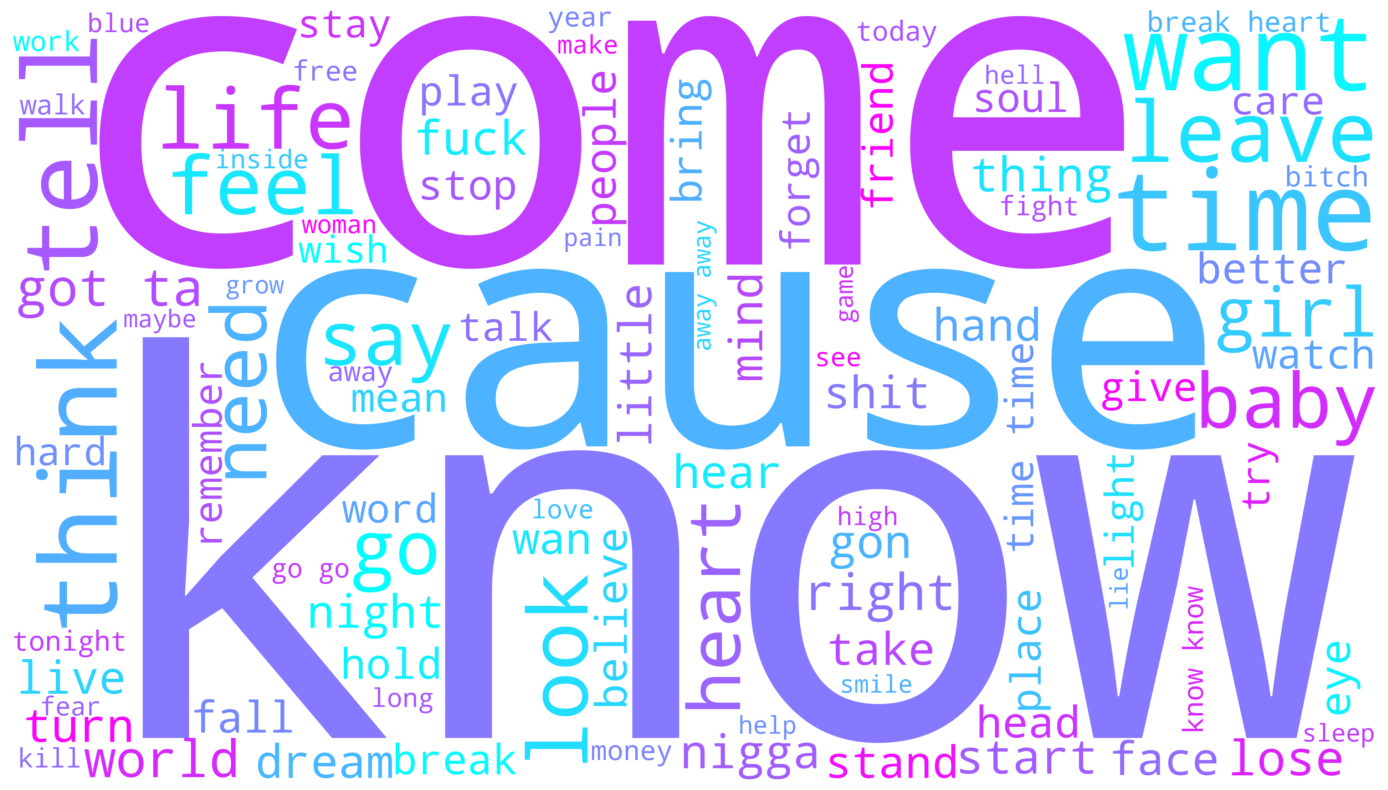

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=3840,
    height=2160,
    max_words=100,
    colormap="cool",
    background_color="white"
).generate(text_wordcloud)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("Graficos/wordcloud_general.png", dpi=300, bbox_inches="tight")
plt.show()

POP:

In [ ]:
df_pop = df_music[df_music["genre"] == "pop"]

text_pop = " ".join(df_pop["lyrics_wordcloud"])

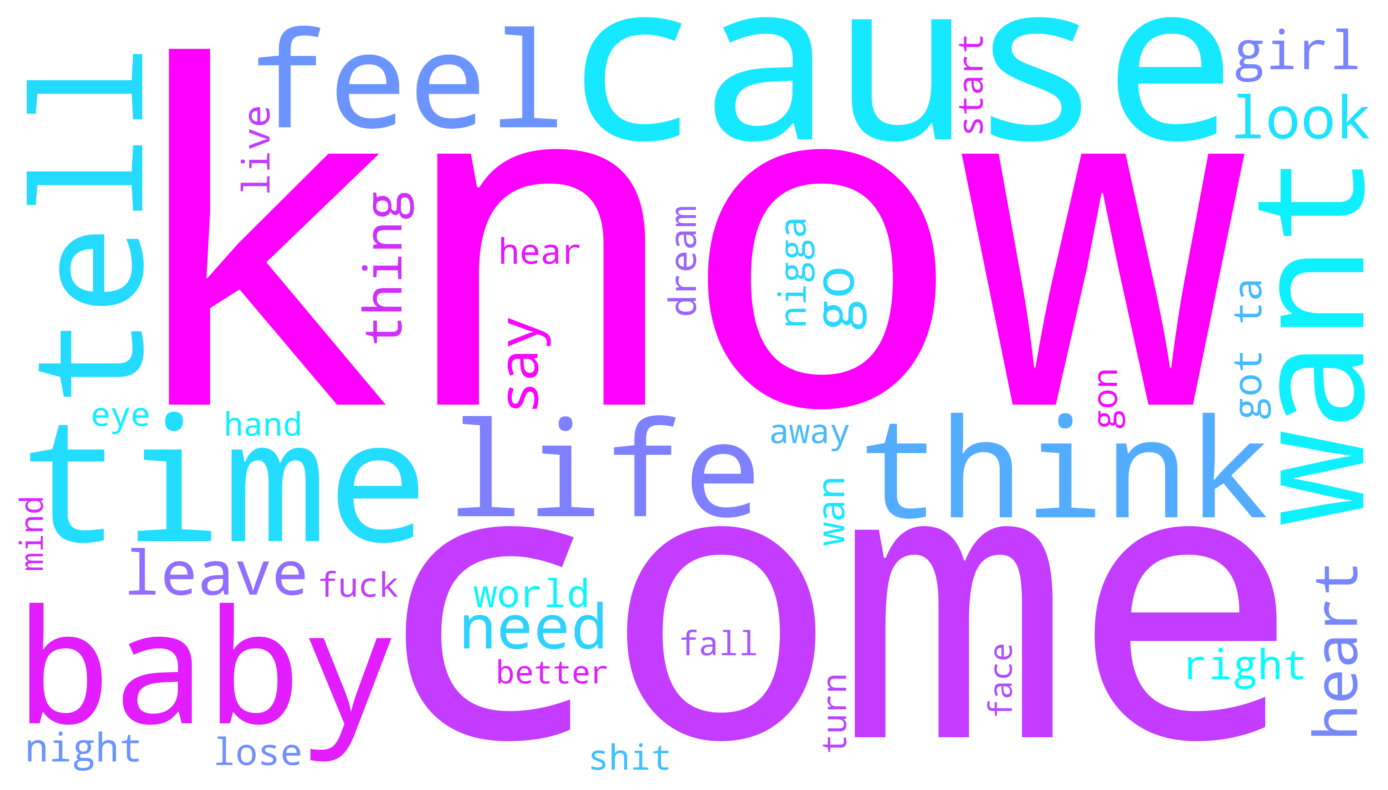

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=3840,
    height=2160,
    max_words=40,
    colormap="cool",
    background_color="white",
    margin=40,
    prefer_horizontal=0.7,
    min_font_size=20
).generate(text_pop)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("Graficos/wordcloud_pop.png", dpi=300, bbox_inches="tight")
plt.show()


HIP HOP:

In [ ]:
df_hip_hop = df_music[df_music["genre"] == "hip hop"]

text_hip_hop = " ".join(df_hip_hop["lyrics_wordcloud"])

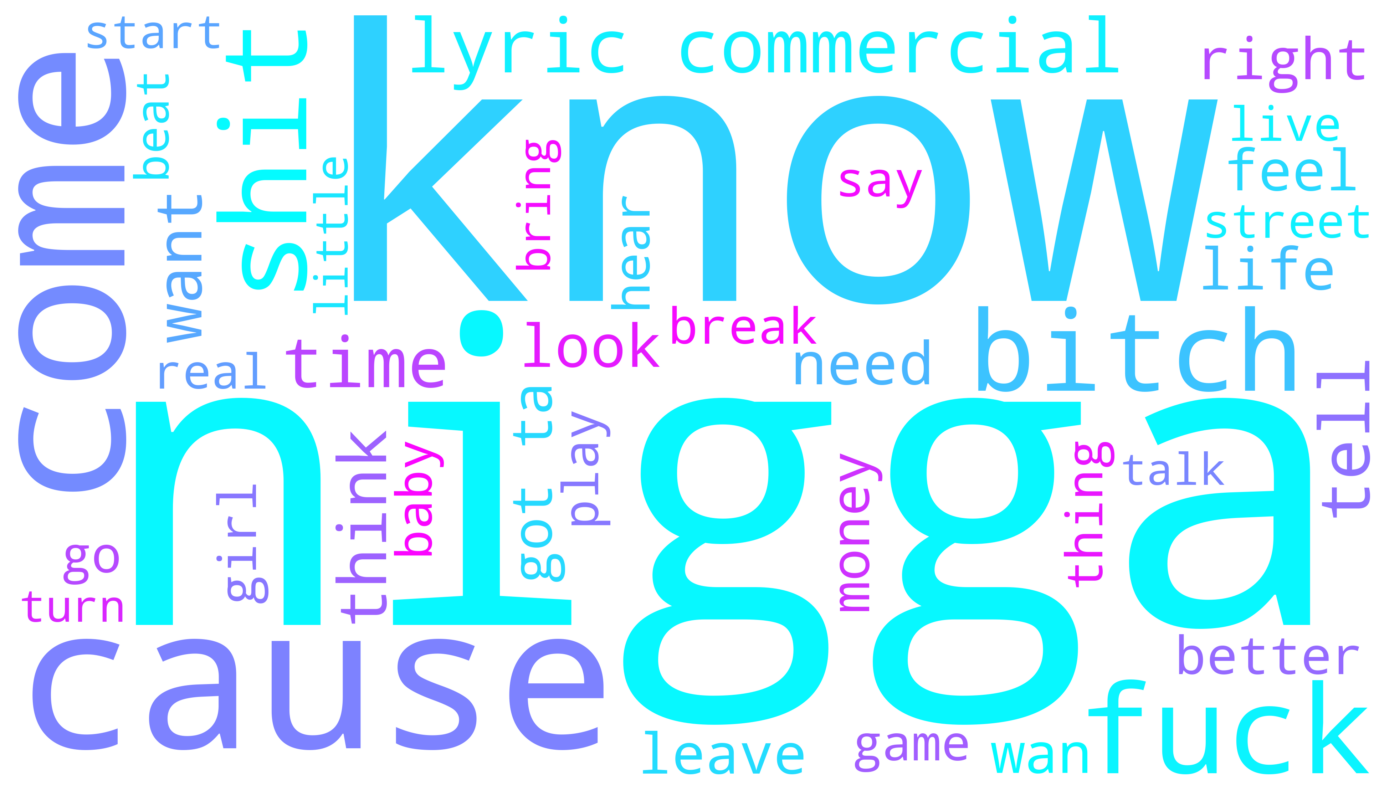

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=3840,
    height=2160,
    max_words=40,
    colormap="cool",
    background_color="white",
    margin=30,
    prefer_horizontal=0.7
).generate(text_hip_hop)

plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.savefig("Graficos/wordcloud_hip_hop.png", dpi=300, bbox_inches="tight")
plt.show()

STREAMGRAPH - Pop & Hip Hop = top 5 words

In [ ]:
import plotly.graph_objects as go
from collections import Counter
import re

def get_top_words(df, genre, n=5, stopwords={"come", "know", "cause", "like", "got", "wan", "gon", "ta", "yeah"}):
    text = " ".join(df[df["genre"] == genre]["lyrics"].dropna().values)
    words = re.findall(r'\b[a-z]+\b', text.lower())
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return [w for w, _ in Counter(words).most_common(n)]

top_pop = get_top_words(df_music, "pop")
top_hiphop = get_top_words(df_music, "hip hop")

print("Top Pop:", top_pop)
print("Top Hip Hop:", top_hiphop)

Top Pop: ['time', 'feel', 'heart', 'away', 'baby']
Top Hip Hop: ['nigga', 'fuck', 'shit', 'bitch', 'time']


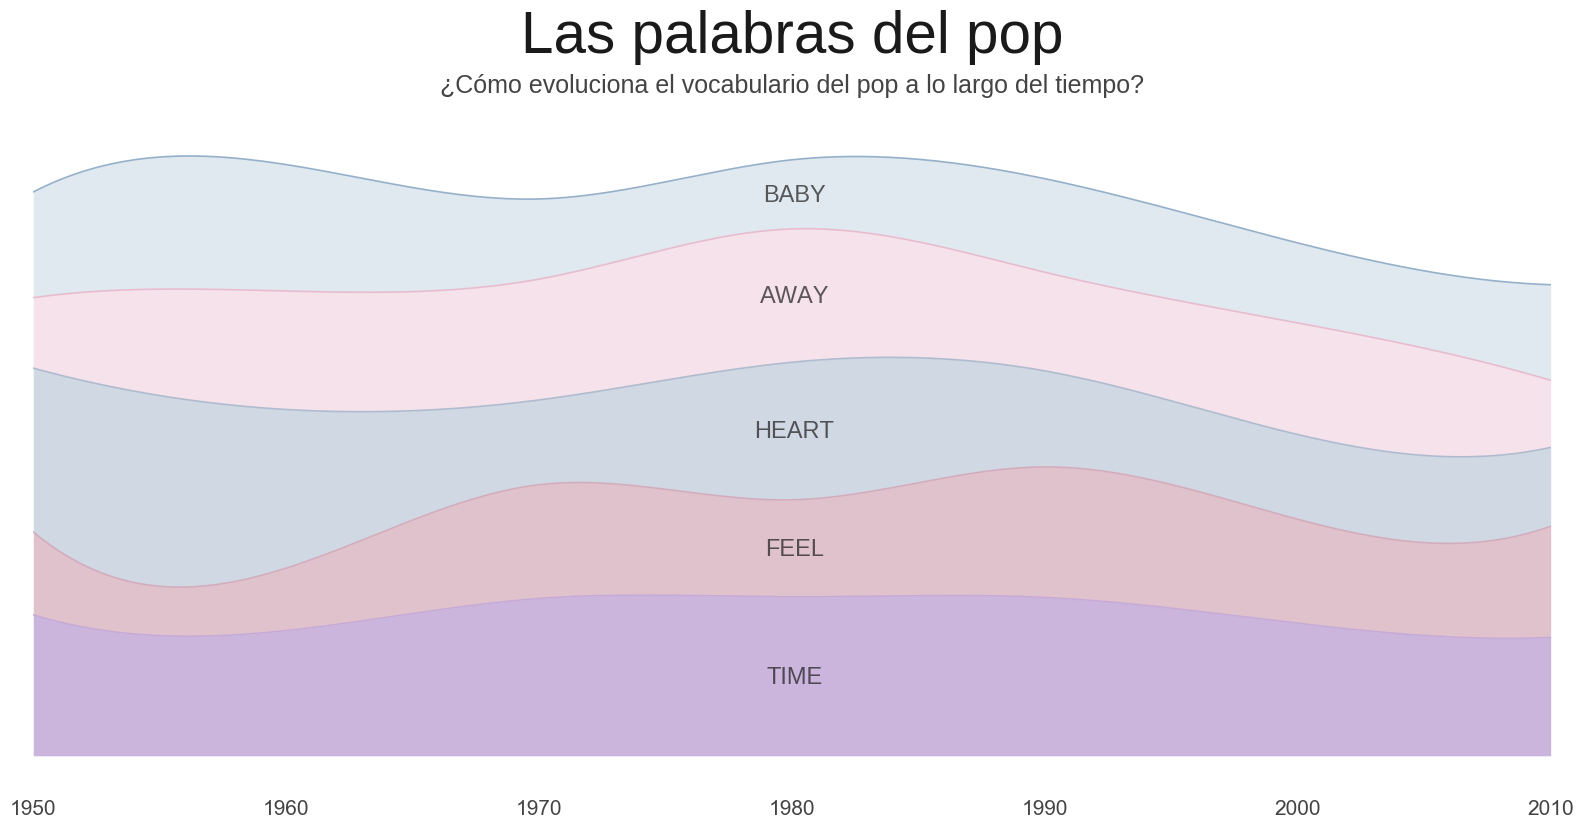

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from scipy.interpolate import make_interp_spline
import re

fm.fontManager.addfont("/Users/patrycjaproniewska/Downloads/Arimo/Arimo-VariableFont_wght.ttf")
prop = fm.FontProperties(fname="/Users/patrycjaproniewska/Downloads/Arimo/Arimo-VariableFont_wght.ttf")

top_pop = ['time', 'feel', 'heart', 'away', 'baby']
decades = sorted(df_music["decade"].dropna().unique())

def count_word_by_decade(df, word, genre):
    counts = []
    for decade in decades:
        lyrics = " ".join(df[(df["decade"] == decade) & (df["genre"] == genre)]["lyrics"].dropna().values).lower()
        words = re.findall(r'\b[a-z]+\b', lyrics)
        total = len(words)
        count = words.count(word)
        counts.append(count / total * 1000 if total > 0 else 0)
    return counts

freq = {word: count_word_by_decade(df_music, word, "pop") for word in top_pop}

x = np.array(decades)
x_smooth = np.linspace(x.min(), x.max(), 300)

colors = ['#C4A8D8', '#D4A8B8', '#A8B8CC', '#E8B8CC', '#8AA8C4']
alphas = [0.85, 0.70, 0.55, 0.40, 0.25]

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

baseline = np.zeros(300)

for i, word in enumerate(top_pop):
    y = np.array(freq[word])
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)
    y_smooth = np.clip(y_smooth, 0, None)

    ax.fill_between(x_smooth, baseline, baseline + y_smooth,
                    color=colors[i], alpha=alphas[i], linewidth=0)
    ax.plot(x_smooth, baseline + y_smooth,
            color=colors[i], linewidth=1.2, alpha=0.9)

    mid = len(x_smooth) // 2
    ax.text(x_smooth[mid], baseline[mid] + y_smooth[mid] / 2,
            word.upper(), ha='center', va='center',
            fontsize=17, color='#1a1a1a', fontweight='bold',
            fontproperties=prop, alpha=0.7)

    baseline = baseline + y_smooth

ax.set_xlim(x_smooth.min(), x_smooth.max())
ax.set_xticks(decades)
ax.set_xticklabels([str(d) for d in decades], fontsize=15,
                   color='#444444', fontfamily='sans-serif')
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.text(0.5, 0.98, "Las palabras del pop",
         ha='center', fontsize=42, color='#1a1a1a',
         fontproperties=prop)
fig.text(0.5, 0.93, "¿Cómo evoluciona el vocabulario del pop a lo largo del tiempo?",
         ha='center', fontsize=18, color='#444444', fontproperties=prop)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("Graficos/streamgraph_pop.png", dpi=300, bbox_inches="tight")
plt.show()

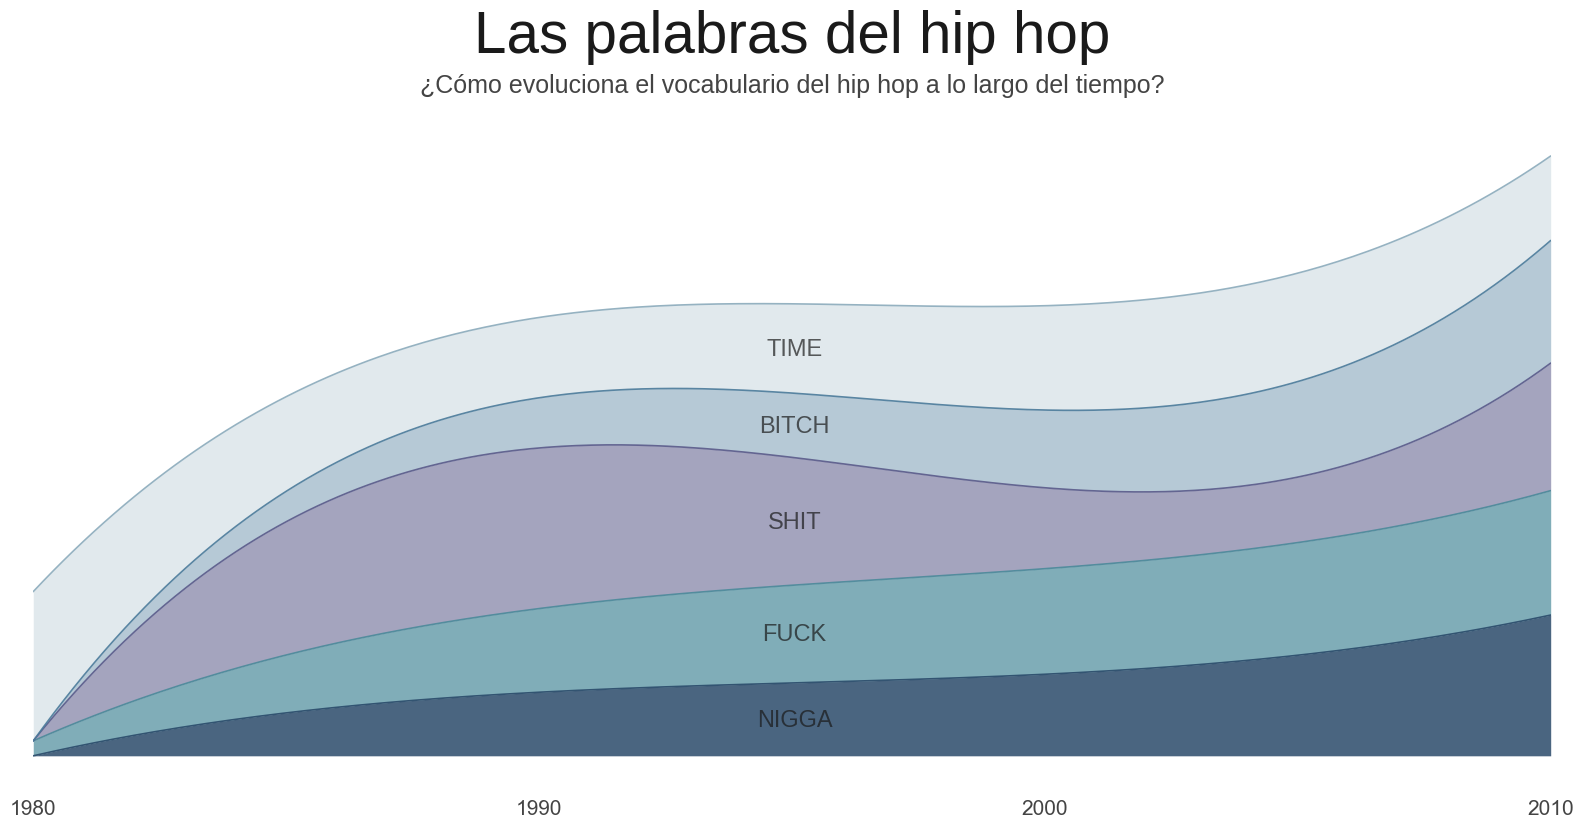

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from scipy.interpolate import make_interp_spline
import re

fm.fontManager.addfont("/Users/patrycjaproniewska/Downloads/Arimo/Arimo-VariableFont_wght.ttf")
prop = fm.FontProperties(fname="/Users/patrycjaproniewska/Downloads/Arimo/Arimo-VariableFont_wght.ttf")

top_hiphop = ['nigga', 'fuck', 'shit', 'bitch', 'time']

# solo décadas donde hay hip hop
decades_hiphop = sorted(df_music[df_music["genre"] == "hip hop"]["decade"].dropna().unique())

def count_word_by_decade(df, word, genre, decades):
    counts = []
    for decade in decades:
        lyrics = " ".join(df[(df["decade"] == decade) & (df["genre"] == genre)]["lyrics"].dropna().values).lower()
        words = re.findall(r'\b[a-z]+\b', lyrics)
        total = len(words)
        count = words.count(word)
        counts.append(count / total * 1000 if total > 0 else 0)
    return counts

freq = {word: count_word_by_decade(df_music, word, "hip hop", decades_hiphop) for word in top_hiphop}

x = np.array(decades_hiphop)
x_smooth = np.linspace(x.min(), x.max(), 300)

colors = ['#2A4A6A', '#4A8A9A', '#5A5A8A', '#4A7A9A', '#8AAABB']
alphas = [0.85, 0.70, 0.55, 0.40, 0.25]

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

baseline = np.zeros(300)

for i, word in enumerate(top_hiphop):
    y = np.array(freq[word])
    spline = make_interp_spline(x, y, k=3)
    y_smooth = spline(x_smooth)
    y_smooth = np.clip(y_smooth, 0, None)

    ax.fill_between(x_smooth, baseline, baseline + y_smooth,
                    color=colors[i], alpha=alphas[i], linewidth=0)
    ax.plot(x_smooth, baseline + y_smooth,
            color=colors[i], linewidth=1.2, alpha=0.9)

    mid = len(x_smooth) // 2
    ax.text(x_smooth[mid], baseline[mid] + y_smooth[mid] / 2,
            word.upper(), ha='center', va='center',
            fontsize=17, color='#1a1a1a', fontweight='bold',
            fontproperties=prop, alpha=0.7)

    baseline = baseline + y_smooth

ax.set_xlim(x_smooth.min(), x_smooth.max())
ax.set_xticks(decades_hiphop)
ax.set_xticklabels([str(d) for d in decades_hiphop], fontsize=15,
                   color='#444444', fontfamily='sans-serif')
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

fig.text(0.5, 0.98, "Las palabras del hip hop",
         ha='center', fontsize=42, color='#1a1a1a',
         fontproperties=prop)
fig.text(0.5, 0.93, "¿Cómo evoluciona el vocabulario del hip hop a lo largo del tiempo?",
         ha='center', fontsize=18, color='#444444', fontproperties=prop)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig("Graficos/streamgraph_hiphop.png", dpi=300, bbox_inches="tight")
plt.show()

VADER:

In [103]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/patrycjaproniewska/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

Crear el analizador:

In [104]:
sia = SentimentIntensityAnalyzer()

Aplicarlo a las letras y guardar solo el compound:

In [105]:
df_music["vader_compound"] = df_music["lyrics"].apply(
    lambda x: sia.polarity_scores(x)["compound"] if isinstance(x, str) else None
).round(2)

In [106]:
vader_by_decade = df_music.groupby("decade")["vader_compound"].mean()
df_decade["vader"] = vader_by_decade

In [ ]:
df_music.head()

,artist_name,track_name,release_date,decade,genre,lyrics,len,dating,violence,world/life,...,valence,energy,topic,age,lyrics_clean,tokens,tokens_clean,tokens_lemma,lyrics_wordcloud,vader_compound
0,mukesh,mohabbat bhi jhoothi,1950,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.339448,0.137110,sadness,1.0,hold time feel break feel untrue convince spea...,"[hold, time, feel, break, feel, untrue, convin...","[hold, time, feel, break, feel, untrue, convin...","[hold, time, feel, break, feel, untrue, convin...",hold time feel break feel untrue convince spea...,0.32
1,frankie laine,i believe,1950,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.325021,0.263240,world/life,1.0,believe drop rain fall grow believe darkest ni...,"[believe, drop, rain, fall, grow, believe, dar...","[believe, drop, rain, fall, grow, believe, dar...","[believe, drop, rain, fall, grow, believe, dar...",believe drop rain fall grow believe darkest ni...,-0.77
2,johnnie ray,cry,1950,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.351814,0.139112,music,1.0,sweetheart send letter goodbye secret feel bet...,"[sweetheart, send, letter, goodbye, secret, fe...","[sweetheart, send, letter, goodbye, secret, fe...","[sweetheart, send, letter, goodbye, secret, fe...",sweetheart send letter goodbye secret feel bet...,0.85
3,pérez prado,patricia,1950,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.775350,0.743736,romantic,1.0,kiss lips want stroll charm mambo chacha merin...,"[kiss, lips, want, stroll, charm, mambo, chach...","[kiss, lips, want, stroll, charm, mambo, chach...","[kiss, lip, want, stroll, charm, mambo, chacha...",kiss lip want stroll charm mambo chacha mering...,0.99
4,giorgos papadopoulos,apopse eida oneiro,1950,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.597073,0.394375,romantic,1.0,till darling till matter know till dream live ...,"[till, darling, till, matter, know, till, drea...","[till, darling, till, matter, know, till, drea...","[till, darling, till, matter, know, till, drea...",till darling till matter know till dream live ...,0.94


In [107]:
df_vader = df_music.groupby(["decade", "genre"])["vader_compound"].mean().reset_index()

In [108]:
df_vader_general = df_music.groupby("decade")["vader_compound"].mean().reset_index()

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcdefaults()
sns.reset_defaults()
sns.set_theme(style="white", context="notebook")

VADER compound evolucion.

In [110]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_vader_general["decade"],
    y=df_vader_general["vader_compound"],
    mode="lines",
    line=dict(color="#B57CFF", width=3, shape="spline", smoothing=1.3),
    fill="tozeroy",
    fillcolor="rgba(181, 124, 255, 0.15)",
    hovertemplate="Década: %{x}<br>VADER: %{y:.3f}<extra></extra>",
    showlegend=False
))

fig.update_layout(
    autosize=True,
    title=dict(
        text="La caída de la positividad",
        font=dict(family="Arimo, Arial, sans-serif", size=55, color="#1a1a1a"),
        x=0.5,
        xanchor="center",
        xref="paper",
        pad=dict(b=10)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="DM Sans, Helvetica Neue, Arial", color="#444444", size=14),
    xaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        tickvals=df_vader_general["decade"].unique(),
        ticktext=[f"   {d}   " for d in df_vader_general["decade"].unique()],
        domain=[0.1, 0.9],
        ticks="outside",
        ticklen=0,
        ticklabelstandoff=10,
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        tickfont=dict(size=19),
        range=[-0.05, 0.5],
        ticklabelstandoff=15,
    ),
    margin=dict(l=140, r=120, t=150, b=120),
    annotations=[
        dict(
            text="¿Cómo cambia el tono emocional medio de las letras década a década?",
            font=dict(family="Arimo, Arial, sans-serif", size=25, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        ),
        dict(
            text="VADER COMPOUND: −1 = muy negativo · 0 = neutral · 1 = muy positivo",
            font=dict(family="Arimo, Arial, sans-serif", size=17, color="#555555"),
            x=0.5,
            y=1.005,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
            yanchor="top",
        )
    ]
)

fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/vader_caida_positividad.png", width=1600, height=900, scale=2)

VADER POR GENERO - GRAFICO DE LINEAS

In [111]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

color_map = {
    "blues":   "#35E0E0",
    "country": "#9DBBE0",
    "jazz":    "#5AA2F8",
    "pop":     "#7D7BFF",
    "rock":    "#A8E6CF",
    "reggae":  "#C93CFF",
    "hip hop": "#FF69B4"
}

genre_order = ["blues", "country", "jazz", "pop", "rock", "reggae", "hip hop"]

df_vader = df_vader.sort_values(["genre", "decade"])
decades = sorted(df_vader["decade"].dropna().unique())

fig = px.line(
    df_vader,
    x="decade",
    y="vader_compound",
    color="genre",
    color_discrete_map=color_map,
    category_orders={"genre": genre_order}
)

fig.update_traces(
    line=dict(width=2.5),
    mode="lines+markers",
    marker=dict(size=5),
    hovertemplate=(
        "<b>%{fullData.name}</b><br>"
        "Década: %{x}<br>"
        "VADER: %{y:.3f}<extra></extra>"
    )
)

fig.add_hline(
    y=0,
    line_width=1,
    line_dash="dash",
    line_color="#cccccc",
)

fig.update_layout(
    autosize=True,
    plot_bgcolor="white",
    paper_bgcolor="white",
    hovermode="x unified",
    font=dict(family="DM Sans, Helvetica Neue, Arial", size=14, color="#444444"),
    title=dict(
        text="El sentimiento según el género",
        x=0.5,
        xanchor="center",
        xref="paper",
        font=dict(family="Arimo, Arial, sans-serif", size=55, color="#1a1a1a"),
        pad=dict(b=10)
    ),
    xaxis=dict(
        title="",
        showgrid=False,
        zeroline=False,
        showline=False,
        tickmode="array",
        tickvals=decades,
        ticktext=[str(d) for d in decades],
        tickfont=dict(size=19),
        range=[decades[0] - 6, decades[-1] + 3],
        ticks="outside",
        ticklen=0,
    ),
    yaxis=dict(
        title="",
        showgrid=False,
        zeroline=False,
        showline=False,
        tickfont=dict(size=19),
        ticklabelstandoff=15,
    ),
    legend=dict(
        title="",
        orientation="v",
        x=0.88,
        y=0.98,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(0,0,0,0)",
        font=dict(family="DM Sans, Helvetica Neue, Arial", size=19)
    ),
    margin=dict(l=100, r=80, t=150, b=20),
    annotations=[
        dict(
            text="¿Cómo evoluciona la media del VADER compound por década en cada género?",
            font=dict(family="Arimo, Arial, sans-serif", size=25, color="#444444"),
            x=0.5,
            y=1.08,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
        ),
        dict(
            text="VADER COMPOUND: −1 = muy negativo · 0 = neutral · 1 = muy positivo",
            font=dict(family="Arimo, Arial, sans-serif", size=17, color="#555555"),
            x=0.5,
            y=1.01,
            xref="paper",
            yref="paper",
            showarrow=False,
            xanchor="center",
            yanchor="top",
        )
    ]
)

fig.show(renderer="browser")

In [ ]:
fig.write_image("Graficos/vader_sentimiento_genero.png", width=1600, height=900, scale=2)